## Assignment: CIFAR-100 Image Classification

Your task is to apply the concepts and techniques learned in this Fashion-MNIST project to the CIFAR-100 dataset. CIFAR-100 is a dataset consisting of 60,000 32x32 color images in 100 classes, with 600 images per class. There are 50,000 training images and 10,000 test images.

Follow these steps:

1.  **Dataset Setup:**
    *   Load the CIFAR-100 dataset.
    *   Preprocess the data (normalize pixel values, one-hot encode labels). Remember that CIFAR-100 images are 32x32 color images, so the input shape will be different from Fashion-MNIST.
    *   Verify the shapes of the processed data.

2.  **Model Building:**
    *   Adapt the ANN and CNN model architectures for the CIFAR-100 dataset. Consider that CIFAR-100 images are color (3 channels) and have a different resolution (32x32). You might need to adjust the input layer and potentially the number of filters or layers in the CNNs for better performance on a more complex dataset.

3.  **Model Training:**
    *   Train the models using the preprocessed CIFAR-100 training data. Use Early Stopping and Model Checkpointing as implemented before.

4.  **Model Evaluation:**
    *   Evaluate the trained models on the CIFAR-100 test set. Compare their performance using loss and accuracy.
    *   Visualize training history and confusion matrices.

5.  **Prediction Analysis:**
    *   Choose the best performing model and analyze its predictions on the CIFAR-100 test set.

**Goal:** To understand how model complexity and architecture choices impact performance on a more challenging image classification dataset like CIFAR-100.

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
(cifar100_train_images, cifar100_train_labels), (cifar100_test_images, cifar100_test_labels) = keras.datasets.cifar100.load_data()

print("CIFAR-100 Training images shape:", cifar100_train_images.shape)
print("CIFAR-100 Testing images shape:", cifar100_test_images.shape)
print("CIFAR-100 Training labels shape:", cifar100_train_labels.shape)
print("CIFAR-100 Testing labels shape:", cifar100_test_labels.shape)

CIFAR-100 Training images shape: (50000, 32, 32, 3)
CIFAR-100 Testing images shape: (10000, 32, 32, 3)
CIFAR-100 Training labels shape: (50000, 1)
CIFAR-100 Testing labels shape: (10000, 1)


e:\Machine Learning\21 Projects in 21 days\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
#normalize
cifar_train_images = cifar100_train_images / 255.0
cifar_test_images = cifar100_test_images / 255.0

In [5]:
cifar_test_images.shape

(10000, 32, 32, 3)

In [6]:
from tensorflow.keras.utils import to_categorical

In [7]:
cifar_train_labels_one_hot = keras.utils.to_categorical(cifar100_train_labels, num_classes=100)
cifar_test_labels_one_hot = keras.utils.to_categorical(cifar100_test_labels, num_classes=100)

In [8]:
print("Training images shape:", cifar_train_images.shape)
print("Testing images shape:", cifar_test_images.shape)
print("Training labels shape:", cifar_train_labels_one_hot.shape)
print("Testing labels shape:", cifar_test_labels_one_hot.shape)

Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)
Training labels shape: (50000, 100)
Testing labels shape: (10000, 100)


In [9]:
ann_model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(100, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 832,484 (3.18 MB)

 Trainable params: 832,484 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint_ann = keras.callbacks.ModelCheckpoint(
    filepath='best_ann_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training ANN model for CIFAR-100...")
ann_history = ann_model.fit(
    cifar_train_images,
    cifar_train_labels_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(cifar_test_images, cifar_test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_ann]
)
print("ANN model training finished.")


Training ANN model for CIFAR-100...
Epoch 1/30
773/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0434 - loss: 4.3633
Epoch 1: val_loss improved from None to 3.81659, saving model to best_ann_model_weights.weights.h5

Epoch 1: finished saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0695 - loss: 4.1277 - val_accuracy: 0.1160 - val_loss: 3.8166
Epoch 2/30
771/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1249 - loss: 3.7541
Epoch 2: val_loss improved from 3.81659 to 3.64145, saving model to best_ann_model_weights.weights.h5

Epoch 2: finished saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1361 - loss: 3.7056 - val_accuracy: 0.1504 - val_loss: 3.6415
Epoch 3/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1590 - loss: 3.5637
Epoch 3: val_loss improved from 3.64145 to 3.59701, saving model to best_ann_model_weights.weights.h5

Epoch 3: finished saving model

CIFAR-100 ANN Test loss: 3.2814
CIFAR-100 ANN Test accuracy: 0.2286
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


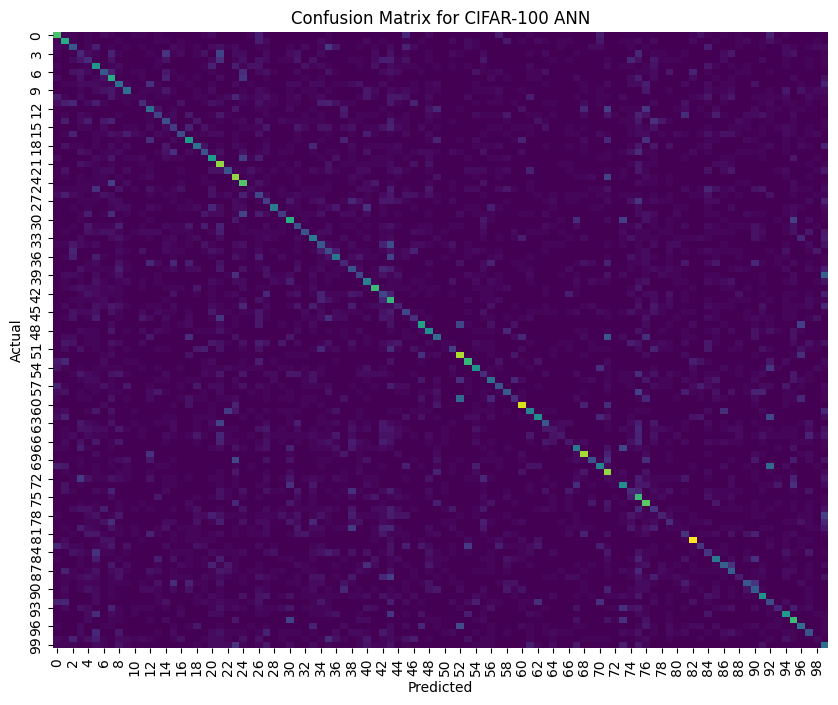

In [11]:
### 4. CIFAR-100 Model Evaluation

#Now that the ANN has finished training on CIFAR-100, we'll load the best weights and evaluate its performance on the test set.  We'll report loss and accuracy and display a confusion matrix to get a sense of where the model is struggling among the 100 classes.

# load best weights saved during training
ann_model.load_weights('best_ann_model_weights.weights.h5')

# evaluate on the CIFAR-100 test data
loss_cifar_ann, acc_cifar_ann = ann_model.evaluate(cifar_test_images, cifar_test_labels_one_hot, verbose=0)
print(f"CIFAR-100 ANN Test loss: {loss_cifar_ann:.4f}")
print(f"CIFAR-100 ANN Test accuracy: {acc_cifar_ann:.4f}")

# confusion matrix for the predictions
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = ann_model.predict(cifar_test_images)
pred_labels = np.argmax(preds, axis=1)
true_labels = cifar100_test_labels.flatten()
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='viridis', cbar=False)
plt.title('Confusion Matrix for CIFAR-100 ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
